# Customer Churn — Exploratory Data Analysis

Explores patterns in the cleaned churn dataset: target distribution, churn by category, numeric distributions, and correlations.

## Imports & Settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Load Data

In [2]:
df = pd.read_csv("../dataset/customer_churn_cleaned_for_eda.csv")

print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


## Target Distribution

How imbalanced is churn in this dataset?

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


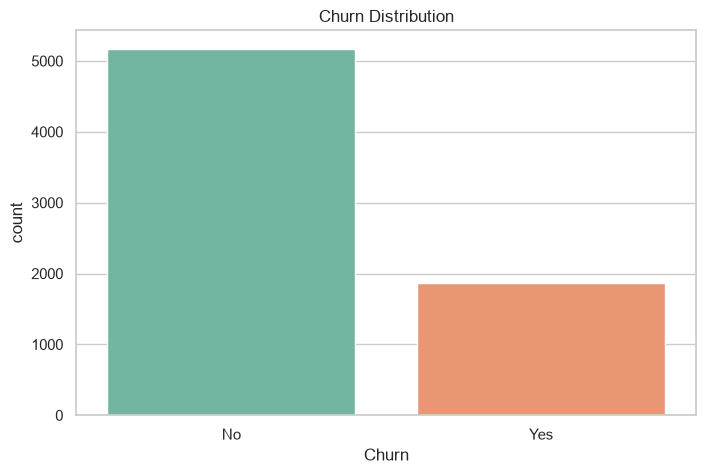

In [5]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print(churn_counts)
print()
print(churn_pct.round(1))

plt.figure()
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False)
plt.title("Churn Distribution")
plt.show()

## Churn by Contract Type

Contract length is usually one of the strongest churn predictors.

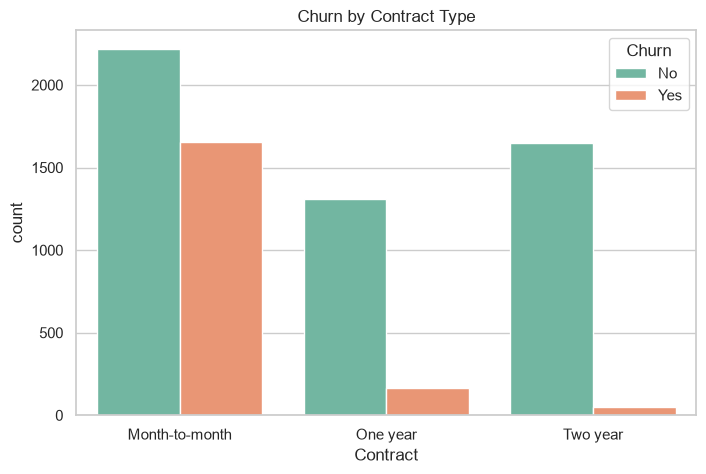

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [6]:
plt.figure()
sns.countplot(data=df, x="Contract", hue="Churn", palette="Set2")
plt.title("Churn by Contract Type")
plt.show()

print(pd.crosstab(df["Contract"], df["Churn"], normalize="index").round(3) * 100)

## Churn by Internet Service & Payment Method

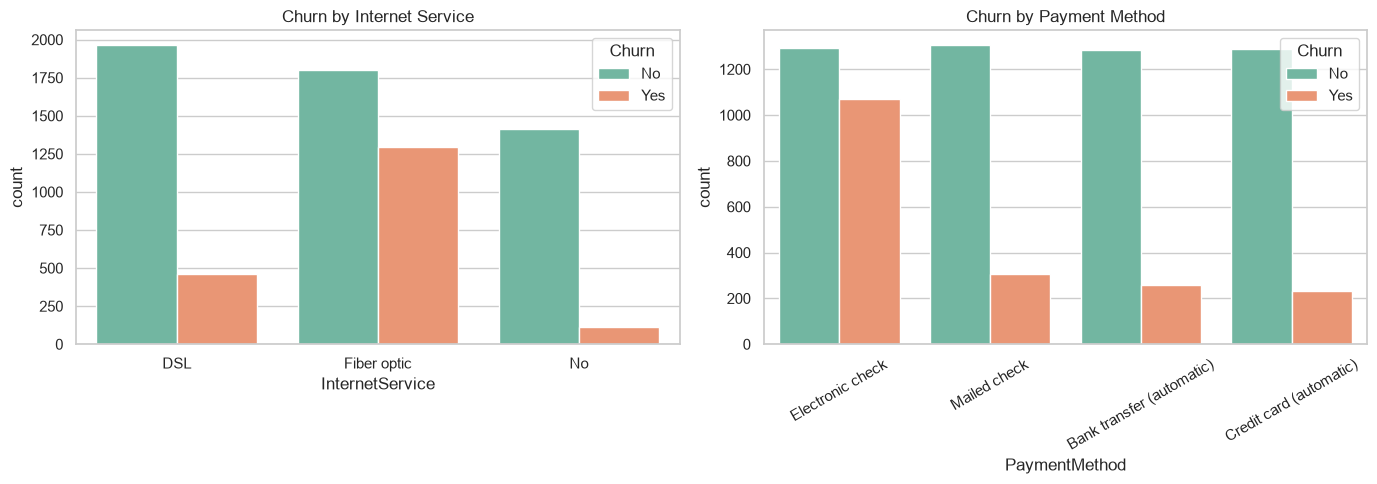

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="InternetService", hue="Churn", palette="Set2", ax=axes[0])
axes[0].set_title("Churn by Internet Service")

sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette="Set2", ax=axes[1])
axes[1].set_title("Churn by Payment Method")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Tenure vs Churn

Do newer customers churn more?

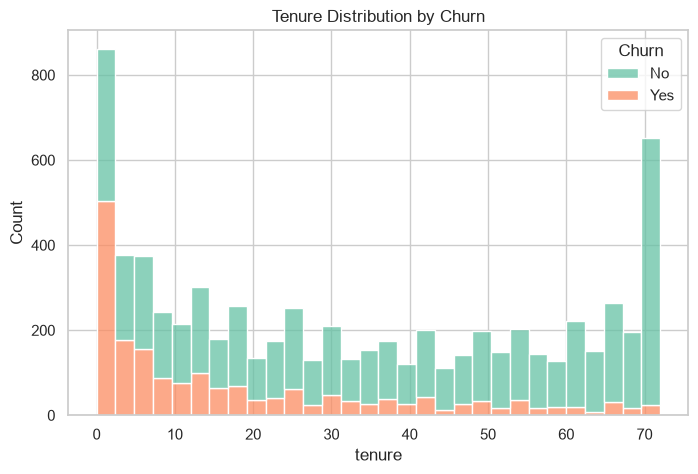

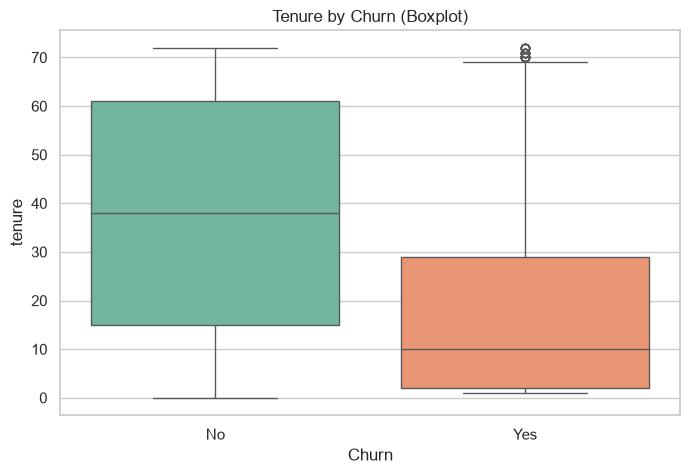

In [8]:
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, palette="Set2")
plt.title("Tenure Distribution by Churn")
plt.show()

plt.figure()
sns.boxplot(data=df, x="Churn", y="tenure", hue="Churn", palette="Set2", legend=False)
plt.title("Tenure by Churn (Boxplot)")
plt.show()

## Monthly & Total Charges vs Churn

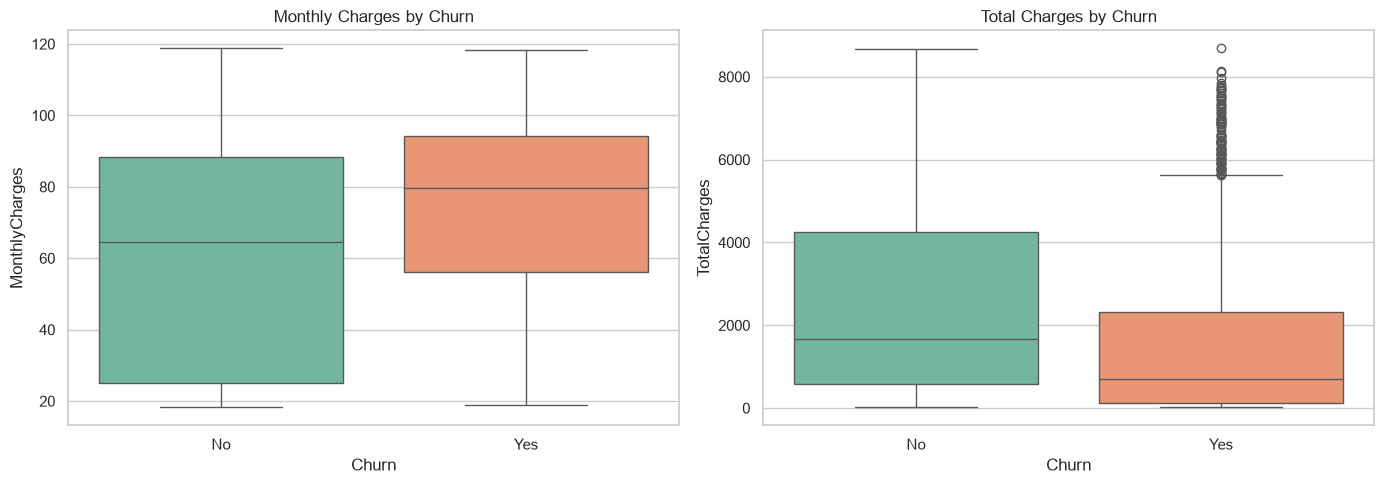

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", hue="Churn", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Total Charges by Churn")

plt.tight_layout()
plt.show()

## Churn by Demographics

Senior citizens, partners, dependents.

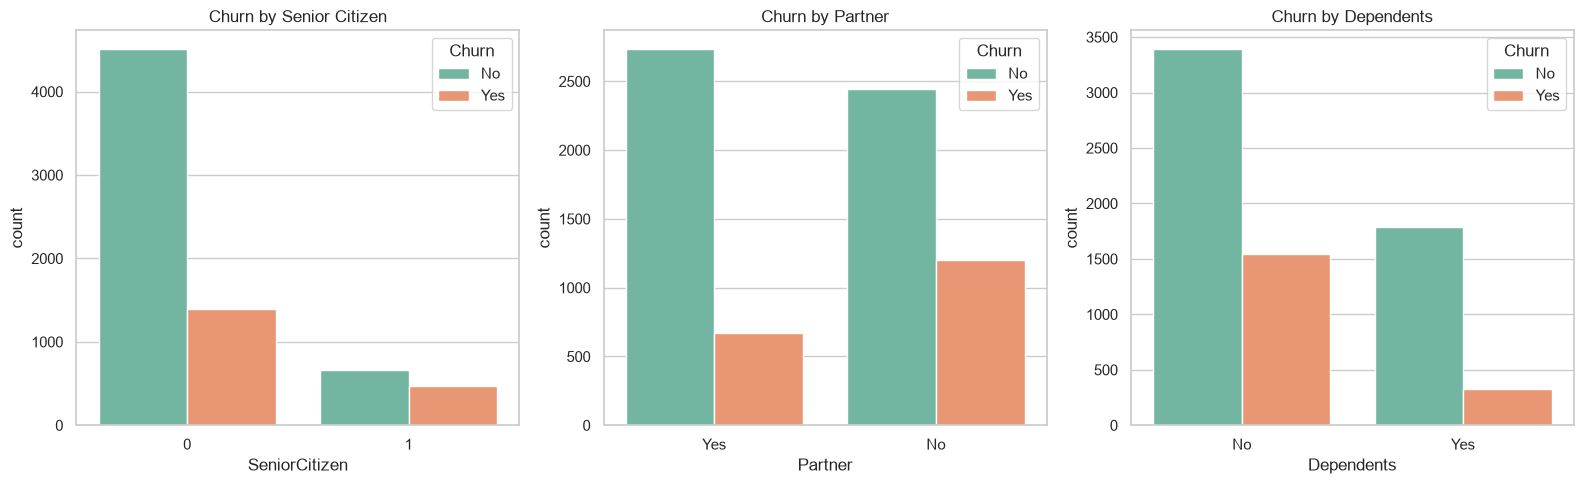

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x="SeniorCitizen", hue="Churn", palette="Set2", ax=axes[0])
axes[0].set_title("Churn by Senior Citizen")

sns.countplot(data=df, x="Partner", hue="Churn", palette="Set2", ax=axes[1])
axes[1].set_title("Churn by Partner")

sns.countplot(data=df, x="Dependents", hue="Churn", palette="Set2", ax=axes[2])
axes[2].set_title("Churn by Dependents")

plt.tight_layout()
plt.show()

## Correlation Heatmap (Numeric Features)

Encodes Churn as 0/1 just for this correlation check — doesn't affect the rest of the notebook.

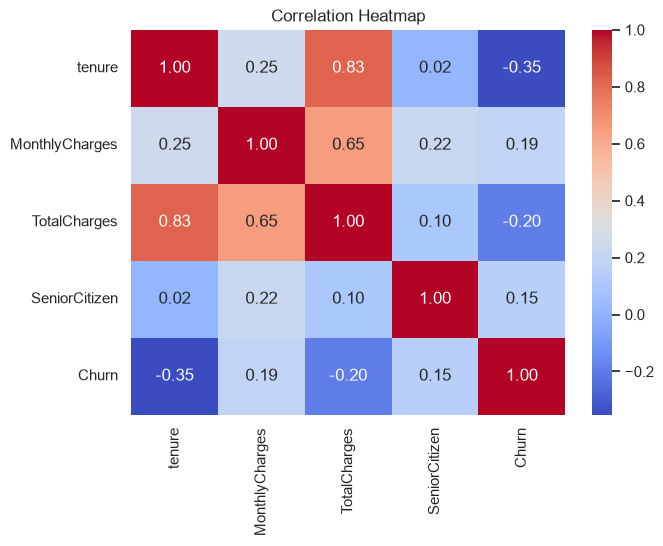

In [11]:
df_corr = df.copy()
df_corr["Churn"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Key Takeaways

*(Fill this in as you review the charts above.)*

In [ ]:
# Summary notes here

20
['customerID' 'gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure'
 'PhoneService' 'MultipleLines' 'InternetService' 'OnlineSecurity'
 'OnlineBackup' 'DeviceProtection' 'TechSupport' 'StreamingTV'
 'StreamingMovies' 'Contract' 'PaperlessBilling' 'PaymentMethod'
 'MonthlyCharges' 'TotalCharges']
